We sart the project as indicated in the instuctions.

First we import all the nessecary libraries and the data set we need to train our code. The data set includes information about various material compositions and wether they are metalic or not.

For our neural network we need numerical features so the composition strings (eg. ZnS) are converted into 132 numerical MAGPIE features. This way we can use them for the training.

In [ ]:
!pip install matminer
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matminer.datasets import load_dataset
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.conversions import StrToComposition

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# ── Shared featurization ────────────────────────────────────────────────────

def featurize_compositions(df: pd.DataFrame,
                           composition_col: str = "composition") -> pd.DataFrame:
    """
    Convert a column of composition strings (e.g. 'ZnS') into
    132 numerical MAGPIE features.

    Returns a new DataFrame with feature columns only (no strings).
    """
    # Step 1: convert string → pymatgen Composition object
    stc = StrToComposition(target_col_id="composition_obj")
    df = stc.featurize_dataframe(df, composition_col, ignore_errors=True)

    # Step 2: compute MAGPIE features from Composition objects
    ep = ElementProperty.from_preset("magpie")
    df = ep.featurize_dataframe(df, col_id="composition_obj", ignore_errors=True)

    # Keep only the numeric feature columns
    feature_cols = ep.feature_labels()
    df = df.dropna(subset=feature_cols)   # drop any failed entries

    return df, feature_cols

# ── Shared PyTorch Dataset ──────────────────────────────────────────────────

class MaterialsDataset(Dataset):
    """
    Simple tabular dataset for materials property prediction.

    X: float32 tensor of shape (n_samples, n_features)
    y: float32 tensor of shape (n_samples, 1)
    """

    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_loader(X, y, batch_size=64, shuffle=True, drop_last=False):
    """Build train and validation DataLoaders."""
    dataset = MaterialsDataset(X, y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last)
    return loader

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━

The "tbench_expt_is_metal" is the dataset that contains all the information we need.

In [ ]:
df_metal = load_dataset("matbench_expt_is_metal")
print(df_metal.head())
print(f"\nShape: {df_metal.shape}")
print(f"\nClass balance:\n{df_metal['is_metal'].value_counts()}")

Fetching matbench_expt_is_metal.json.gz from https://ml.materialsproject.org/projects/matbench_expt_is_metal.json.gz to /usr/local/lib/python3.12/dist-packages/matminer/datasets/matbench_expt_is_metal.json.gz


Fetching https://ml.materialsproject.org/projects/matbench_expt_is_metal.json.gz in MB: 0.034816MB [00:00, 10.71MB/s]                 

         composition  is_metal
0           Ag(AuS)2      True
1         Ag(W3Br7)2      True
2   Ag0.5Ge1Pb1.75S4     False
3  Ag0.5Ge1Pb1.75Se4     False
4             Ag2BBr      True

Shape: (4921, 2)

Class balance:
is_metal
False    2470
True     2451
Name: count, dtype: int64


Here is where the data are tranformed from raw to a format that can be used for machine learning. From this we also get the percentage of the materials that are metallic and those that are not.

In [ ]:
df_metal, feature_cols = featurize_compositions(df_metal, composition_col="composition")

X_cls = df_metal[feature_cols].values.astype(np.float32)
y_cls = df_metal["is_metal"].astype(int).values.astype(np.float32)

print(f"Feature matrix shape: {X_cls.shape}")
print(f"Class balance — metals: {y_cls.mean():.1%} | non-metals: {1-y_cls.mean():.1%}")

StrToComposition:   0%|          | 0/4921 [00:00<?, ?it/s]

ElementProperty:   0%|          | 0/4921 [00:00<?, ?it/s]

Feature matrix shape: (4921, 132)
Class balance — metals: 49.8% | non-metals: 50.2%


Now we have to split the data. 80% of the available data will be used for the traing and the rest 20% for the test of the training proccess.

This 80% will be futher split in to again 80% and 20%. Now, this amount of 80% will actually be udes for the training, so the 64% of the starting amount of data. The first **validation** will be with the rest 20%, so the 16% of the initial data. After this process ends, the whole training will be **tested** with the 20% of data we set aside in the beginning.

To do all of this, we also create batches with a size of 64.

In [ ]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42,
    stratify=y_cls    # preserve class balance in both splits
)

X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(
    X_train_c, y_train_c, test_size=0.2, random_state=42,
    stratify=y_train_c
)

scaler_c = StandardScaler()
X_train_c = scaler_c.fit_transform(X_train_c)
X_val_c   = scaler_c.transform(X_val_c)
X_test_c  = scaler_c.transform(X_test_c)

train_loader_c = make_loader(X_train_c, y_train_c, batch_size=64, shuffle=True, drop_last=True)
val_loader_c   = make_loader(X_val_c, y_val_c, batch_size=64,shuffle=False, drop_last=False)
test_loader_c  = make_loader(X_test_c, y_test_c, batch_size=256, shuffle=False, drop_last=False)

Train samples: 64% of total -> 3148

Validation samples: 16% of total -> 788


---


Train + Valdidation samples = 80% of total


---


Test samples: 20% of total -> 988



In [ ]:
print(f"Train samples: {len(train_loader_c.dataset)}")
print(f"Validation samples: {len(val_loader_c.dataset)}")
print(f"Test samples: {len(test_loader_c.dataset)}")

Train samples: 3148
Validation samples: 788
Test samples: 985


We create a feed worward network. First layer has 132 features and they are transformed into 32 intrenal ones. These become 8 in the next layer and then 2. We also add a non-linear activation function.

Finaly the torxh.softmax takes the outputs and tranforms them into probability, up to 1. This way it shows how probable a material is metal or non metal.

In [ ]:
class MetalClassifierNet(nn.Module):
    """
    Feed-forward network for binary classification.
    """
    def __init__(self, n_features: int,dropout:float=0.4):
        super().__init__()
        self.fc1 = nn.Linear(n_features,32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32,8)
        self.fc3 = nn.Linear(8,2)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        x = self.relu(x)


        x=torch.softmax(x, dim=1)
        return x # Output raw logits

We now indtroduse the optimizer "Adam"

In [ ]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_cls = MetalClassifierNet(n_features=X_train_c.shape[1])
optimizer_cls = optim.Adam(model_cls.parameters(), lr=0.0001)
criterion_cls = nn.CrossEntropyLoss()

In this step we instroduce the train epoches for the training model, with forward and backword passes, loss calculation and parameters updates. With the evaluate function we assess the model´s performance.

In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
  model.train()
  total_loss = 0.0
  for X_batch, y_batch in loader:
    X_batch = X_batch.to(device)
    y_batch = y_batch.to(device).squeeze().to(torch.long)

    optimizer.zero_grad()

    predictions = model(X_batch)
    loss = criterion(predictions, y_batch)

    loss.backward()

    optimizer.step()

    total_loss += loss.item()

  return total_loss / len(loader)

def evaluate(model, loader, criterion, device):
  model.eval()
  total_loss = 0.0
  with torch.no_grad():
    for X_batch, y_batch in loader:
     X_batch = X_batch.to(device)
     y_batch = y_batch.to(device).squeeze().to(torch.long)

     predictions = model(X_batch)

     loss = criterion(predictions, y_batch)

     total_loss += loss.item()


  return total_loss / len(loader)

After, we put the main training loop, for a specific number of epoches to train the model and evaluate its performance, using the training and validation datasets. Also, we visualized the prosses of training and validation loss with a plot.

Epoch 1/80: Train Loss = 0.6856, Val Loss = 0.6783
Epoch 2/80: Train Loss = 0.6725, Val Loss = 0.6651
Epoch 3/80: Train Loss = 0.6572, Val Loss = 0.6466
Epoch 4/80: Train Loss = 0.6363, Val Loss = 0.6245
Epoch 5/80: Train Loss = 0.6141, Val Loss = 0.6026
Epoch 6/80: Train Loss = 0.5930, Val Loss = 0.5834
Epoch 7/80: Train Loss = 0.5746, Val Loss = 0.5671
Epoch 8/80: Train Loss = 0.5595, Val Loss = 0.5537
Epoch 9/80: Train Loss = 0.5465, Val Loss = 0.5427
Epoch 10/80: Train Loss = 0.5354, Val Loss = 0.5332
Epoch 11/80: Train Loss = 0.5253, Val Loss = 0.5244
Epoch 12/80: Train Loss = 0.5164, Val Loss = 0.5162
Epoch 13/80: Train Loss = 0.5074, Val Loss = 0.5089
Epoch 14/80: Train Loss = 0.5004, Val Loss = 0.5020
Epoch 15/80: Train Loss = 0.4943, Val Loss = 0.4963
Epoch 16/80: Train Loss = 0.4880, Val Loss = 0.4914
Epoch 17/80: Train Loss = 0.4836, Val Loss = 0.4872
Epoch 18/80: Train Loss = 0.4791, Val Loss = 0.4837
Epoch 19/80: Train Loss = 0.4762, Val Loss = 0.4805
Epoch 20/80: Train Lo

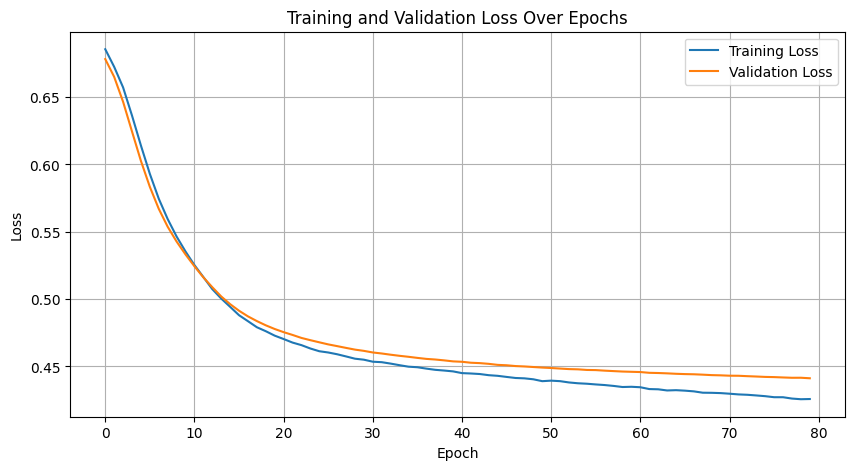

In [ ]:
history = {"train_loss": [], "val_loss": []}

N_EPOCHS = 80
for epoch in range(N_EPOCHS):
  train_loss = train_epoch(model_cls, train_loader_c, optimizer_cls, criterion_cls, device)
  val_loss = evaluate(model_cls, val_loader_c, criterion_cls, device)

  history["train_loss"].append(train_loss)
  history["val_loss"].append(val_loss)

  print(f"Epoch {epoch+1}/{N_EPOCHS}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

# Plot graphs once finished with matplotlib to see the evolution of the losses
plt.figure(figsize=(10, 5))
plt.plot(history["train_loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Epochs")
plt.legend()
plt.grid(True)
plt.show()

Here, we do the same process of trainig and validating but with the data from the test loader.

Epoch 1/80: Train Loss = 0.4252, Test Loss = 0.4375
Epoch 2/80: Train Loss = 0.4243, Test Loss = 0.4371
Epoch 3/80: Train Loss = 0.4240, Test Loss = 0.4369
Epoch 4/80: Train Loss = 0.4239, Test Loss = 0.4366
Epoch 5/80: Train Loss = 0.4230, Test Loss = 0.4368
Epoch 6/80: Train Loss = 0.4226, Test Loss = 0.4362
Epoch 7/80: Train Loss = 0.4229, Test Loss = 0.4361
Epoch 8/80: Train Loss = 0.4224, Test Loss = 0.4361
Epoch 9/80: Train Loss = 0.4217, Test Loss = 0.4357
Epoch 10/80: Train Loss = 0.4218, Test Loss = 0.4353
Epoch 11/80: Train Loss = 0.4207, Test Loss = 0.4351
Epoch 12/80: Train Loss = 0.4209, Test Loss = 0.4352
Epoch 13/80: Train Loss = 0.4204, Test Loss = 0.4349
Epoch 14/80: Train Loss = 0.4201, Test Loss = 0.4348
Epoch 15/80: Train Loss = 0.4190, Test Loss = 0.4344
Epoch 16/80: Train Loss = 0.4195, Test Loss = 0.4346
Epoch 17/80: Train Loss = 0.4194, Test Loss = 0.4344
Epoch 18/80: Train Loss = 0.4190, Test Loss = 0.4342
Epoch 19/80: Train Loss = 0.4182, Test Loss = 0.4339
Ep

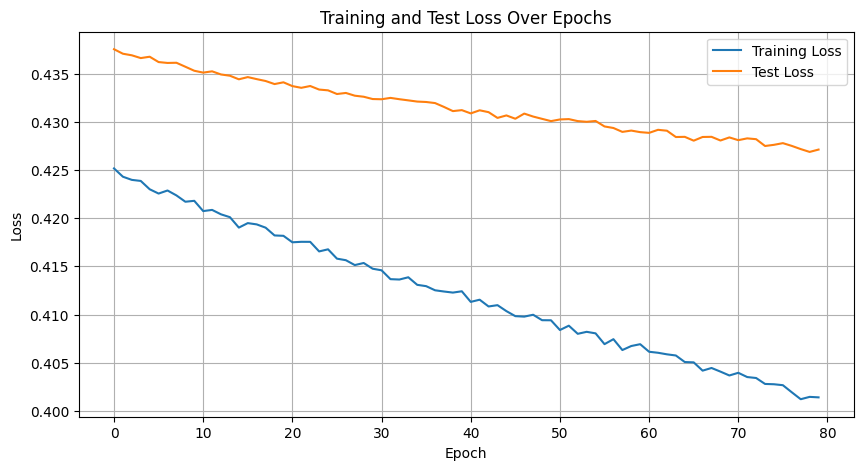

In [ ]:
history = {"train_loss": [], "test_loss": []}

N_EPOCHS = 80
for epoch in range(N_EPOCHS):
  train_loss = train_epoch(model_cls, train_loader_c, optimizer_cls, criterion_cls, device)
  test_loss = evaluate(model_cls, test_loader_c, criterion_cls, device)

  history["train_loss"].append(train_loss)
  history["test_loss"].append(test_loss)

  print(f"Epoch {epoch+1}/{N_EPOCHS}: Train Loss = {train_loss:.4f}, Test Loss = {test_loss:.4f}")

# Plot graphs once finished with matplotlib to see the evolution of the losses
plt.figure(figsize=(10, 5))
plt.plot(history["train_loss"], label="Training Loss")
plt.plot(history["test_loss"], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss Over Epochs")
plt.legend()
plt.grid(True)
plt.show()

This function checks how well our model guessed correctly by comparing its answers to the real ones. It counts how many times the model was right and then gives us a percentage score.

In [ ]:
def calculate_accuracy(model, loader, device):
    model.eval()  # Set the model to evaluation mode
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():  # No need to calculate gradients during evaluation
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).squeeze()

            outputs = model(X_batch)
            # Get the predicted class (index of the max logit)
            _, predicted = torch.max(outputs.data, 1)

            total_samples += y_batch.size(0)
            correct_predictions += (predicted == y_batch.long()).sum().item()

    accuracy = 100 * correct_predictions / total_samples
    return accuracy

We calculate the accuracy on the test set using the trained model.

In [ ]:
test_accuracy = calculate_accuracy(model_cls, test_loader_c, device)
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 88.43%


Re-run the training loop, but this time we'll also track and plot the accuracy for both training and validation sets.

In [ ]:
# Re-initialize the model and optimizer for a fresh training run
model_cls = MetalClassifierNet(n_features=X_train_c.shape[1])
optimizer_cls = optim.Adam(model_cls.parameters(), lr=0.0001)
criterion_cls = nn.CrossEntropyLoss()

model_cls.to(device)

history_new = {"train_loss": [], "val_loss": [], "train_accuracy": [], "val_accuracy": []}

N_EPOCHS = 100
print(f"\nStarting new training loop with {N_EPOCHS} epochs...")

for epoch in range(N_EPOCHS):
    train_loss = train_epoch(model_cls, train_loader_c, optimizer_cls, criterion_cls, device)
    val_loss = evaluate(model_cls, val_loader_c, criterion_cls, device)

    train_accuracy = calculate_accuracy(model_cls, train_loader_c, device)
    val_accuracy = calculate_accuracy(model_cls, val_loader_c, device)

    history_new["train_loss"].append(train_loss)
    history_new["val_loss"].append(val_loss)
    history_new["train_accuracy"].append(train_accuracy)
    history_new["val_accuracy"].append(val_accuracy)

    print(f"Epoch {epoch+1}/{N_EPOCHS}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, Train Acc = {train_accuracy:.2f}%, Val Acc = {val_accuracy:.2f}%")

print("\nTraining complete!")


Starting new training loop with 100 epochs...
Epoch 1/100: Train Loss = 0.6884, Val Loss = 0.6806, Train Acc = 49.65%, Val Acc = 49.75%
Epoch 2/100: Train Loss = 0.6756, Val Loss = 0.6657, Train Acc = 51.72%, Val Acc = 52.92%
Epoch 3/100: Train Loss = 0.6581, Val Loss = 0.6442, Train Acc = 64.89%, Val Acc = 67.77%
Epoch 4/100: Train Loss = 0.6358, Val Loss = 0.6212, Train Acc = 72.19%, Val Acc = 75.76%
Epoch 5/100: Train Loss = 0.6132, Val Loss = 0.5994, Train Acc = 78.79%, Val Acc = 80.20%
Epoch 6/100: Train Loss = 0.5911, Val Loss = 0.5791, Train Acc = 82.53%, Val Acc = 82.87%
Epoch 7/100: Train Loss = 0.5711, Val Loss = 0.5618, Train Acc = 83.64%, Val Acc = 83.63%
Epoch 8/100: Train Loss = 0.5542, Val Loss = 0.5471, Train Acc = 84.02%, Val Acc = 83.88%
Epoch 9/100: Train Loss = 0.5400, Val Loss = 0.5348, Train Acc = 84.22%, Val Acc = 84.01%
Epoch 10/100: Train Loss = 0.5278, Val Loss = 0.5246, Train Acc = 84.18%, Val Acc = 84.26%
Epoch 11/100: Train Loss = 0.5168, Val Loss = 0.5160

Here are the plots for both loss and accuracy over the training epochs:

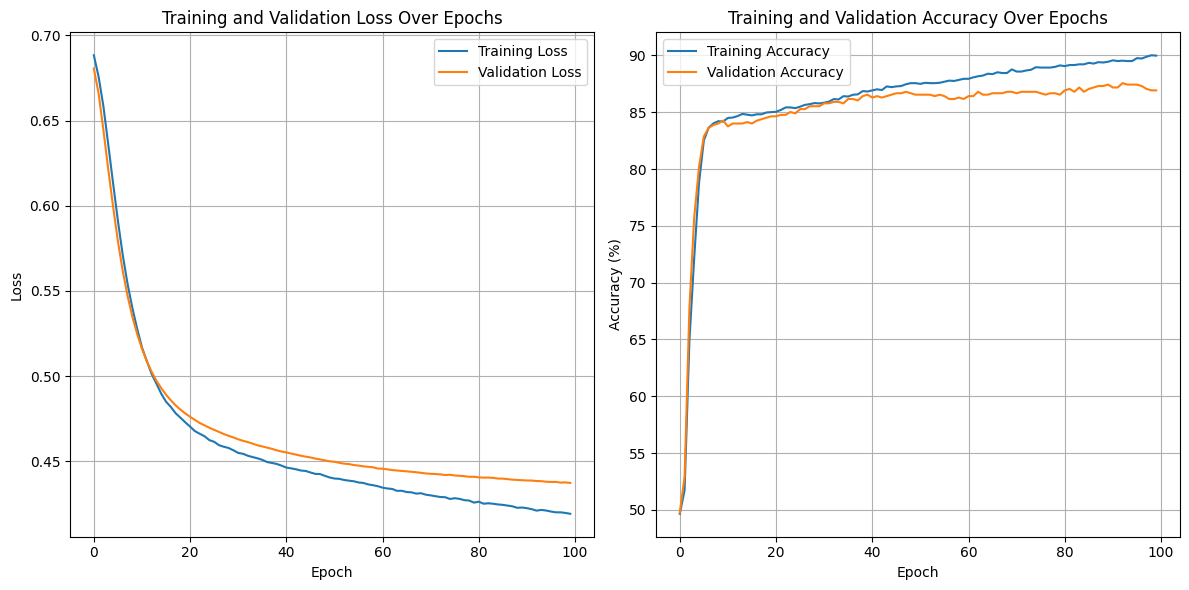

In [ ]:
# Plotting Loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(history_new["train_loss"], label="Training Loss")
plt.plot(history_new["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Epochs")
plt.legend()
plt.grid(True)

# Plotting Accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(history_new["train_accuracy"], label="Training Accuracy")
plt.plot(history_new["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy Over Epochs")
plt.legend()
plt.grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()